# 样章 · 系统边界、变量与单位

## 学习目标与先修知识

完成后，你能划定系统边界（system boundary），区分存量（stock）与流量（flow），并用单位和收支（mass balance）关系核对物质量的变化。

**先修知识**：基础 Python 的变量、循环和函数，以及中学代数；无需微积分。


## 具体问题

一种示踪物质（tracer）进入一个理想的体内空间。半个时间单位后，里面剩多少？
先把空间画成一个边界：穿过边界的进入与离开是流量，边界内“此刻有多少”是存量。
我们暂时用给定的清除速率做记账，下一节再让清除取决于当前存量。

## 初步实验

初始有 2 U，连续三个区间各长 0.5 T，流入速率均为 2 U/T，
清除速率依次为 1、1.5、2 U/T。先手算第一步：2 + 0.5 × (2 − 1) = 2.5 U。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
from systems_science.theme import DATA_COLORS, SERIES_COLORS

plot_style()

In [2]:
initial_amount = 2.0
dt = 0.5
input_rates = [2.0, 2.0, 2.0]
removal_rates = [1.0, 1.5, 2.0]
amounts = [initial_amount]
for inflow_rate, removal_rate in zip(input_rates, removal_rates):
    amounts.append(amounts[-1] + dt * (inflow_rate - removal_rate))
print("各时刻的物质量 / U：", amounts)
assert np.allclose(amounts, [2.0, 2.5, 2.75, 2.75])

各时刻的物质量 / U： [2.0, 2.5, 2.75, 2.75]


## 模型假设

边界内没有其他产生或损失，流量在每个区间内不变，所给速率是教学记账数值。
空间足够混合，不记录物质在空间中的位置。这里的 A 是总物质量，不是“每单位体积有多少”的浓度（concentration）。

| 量 | 含义 | 单位 |
|---|---|---|
| A | 室内存量 | U |
| 输入速率、清除速率 | 每单位时间穿过边界的量 | U/T |
| Δt | 一个区间持续多久 | T |
| 输入量、清除量 | 一个区间实际穿过的量 | U |

## 数学解释与推导

“速率 × 持续时间 = 这段时间的数量”，所以单位关系是 (U/T) × T = U。
若 Aₙ 表示第 n 个区间开始时的物质量，qᵢₙ、qₒᵤₜ 表示区间内恒定流率，则

$$A_{n+1}=A_n+\Delta t\,(q_{\mathrm{in}}-q_{\mathrm{out}}).$$

把每一步相加，中间状态（state）抵消，只留下：最终存量 − 初始存量 = 总流入量 − 总流出量。
这叫收支或守恒检查（conservation check）。它不能保证给定流量有生理依据，但能检查账目是否一致。

## 核心实现

下面把每一步拆成可核对的账目。`zip` 将同一区间的流入和清除放在一起，
`enumerate` 提供区间编号；这些是普通 Python 操作。

| 区间 | 起点 / U | 流入量 / U | 流出量 / U | 终点 / U |
| --- | --- | --- | --- | --- |
| 0 | 2 | 1 | 0.5 | 2.5 |
| 1 | 2.5 | 1 | 0.75 | 2.75 |
| 2 | 2.75 | 1 | 1 | 2.75 |

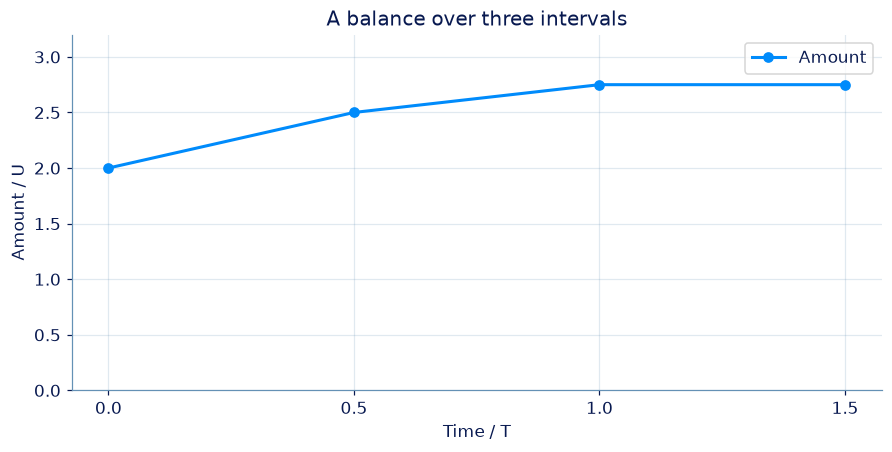

In [3]:
rows = []
for n, (q_in, q_out) in enumerate(zip(input_rates, removal_rates)):
    rows.append([n, amounts[n], q_in * dt, q_out * dt, amounts[n+1]])
display(Markdown(show_table(["区间", "起点 / U", "流入量 / U", "流出量 / U", "终点 / U"], rows)))
times = np.arange(len(amounts)) * dt  # 0、0.5、1、1.5 T
fig, ax = plt.subplots()
ax.plot(times, amounts, "o-", label="Amount")
ax.set_xticks(times)
ax.set(xlabel="Time / T", ylabel="Amount / U", title="A balance over three intervals", ylim=(0, 3.2))
ax.legend()
plt.show()

## 对照实验

故意漏掉 Δt，会把“每单位时间的数量”当成“该区间的数量”。比较正确与错误的结果。
再检查流入等于流出时，存量会不会变化。

In [4]:
wrong_final = initial_amount + sum(q_in - q_out for q_in, q_out in zip(input_rates, removal_rates))
correct_final = amounts[-1]
assert np.isclose(correct_final - initial_amount, dt * sum(input_rates) - dt * sum(removal_rates))
unchanged = initial_amount + dt * (2.0 - 2.0)
assert unchanged == initial_amount
display(Markdown(show_table(["算法", "最终存量 / U"], [["含区间时长", correct_final], ["错误：遗漏时长", wrong_final]])))

| 算法 | 最终存量 / U |
| --- | --- |
| 含区间时长 | 2.75 |
| 错误：遗漏时长 | 3.5 |

## 结果解释

三个区间后得到 2.75 U；漏乘 0.5 T 得到 3.5，数值不同且单位不成立。
第三个区间仍有 1 U 进入、1 U 离开，存量保持 2.75 U。“存量不变”不等于“没有流动”。
同一存量也可能对应不同流量：0 进 0 出与 2 进 2 出，都能维持它。

## 练习与参考资料

先独立作答，再提交核对。每道题的题面和输入输出示例如下。

### 第 1 题 · 单项选择题：存量与流量的单位

A 表示边界内的存量（stock），q 表示流量（flow）。物质量和时间的单位分别为 U、T。哪组单位能使 A_next = A + Δt(q_in − q_out) 成立？

- **A.** A 为 U，q 为 U/T，Δt·q 为 U
- **B.** A 为 U/T，q 为 U，Δt·q 为 U·T
- **C.** A、q 和 Δt·q 都为 U
- **D.** A 为 U，q 为 U/T，Δt·q 为 U/T

[作答：存量与流量的单位](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=stock-flow-units)

### 第 2 题 · Python 计算题：计算逐段收支

给定初始存量（stock） A0 和每个区间的流入、流出速率，按收支（mass balance）计算各区间末的存量；区间内速率恒定。

**函数与代码模板**

```python
def solve(
    A0: float,
    durations: list[float],
    inflows: list[float],
    outflows: list[float],
) -> list[float]:
    # 返回 amounts 列表。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A0` | `float` | 计算开始时的物质量。 | U |
| `durations` | `list[float]` | durations[i] 是第 i 个区间的持续时间。 | T |
| `inflows` | `list[float]` | inflows[i] 是第 i 个区间的流入速率。 | U/T |
| `outflows` | `list[float]` | outflows[i] 是第 i 个区间的流出速率。 | U/T |

**返回值**

直接返回 amounts（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `amounts` | `list[float]` | 按时间顺序返回物质量；第一项为 A0，后续每项为一个区间末的物质量。 | U |

**计算规则**

区间内流率恒定。每个区间结束时的物质量 = 该区间开始时的物质量 + 持续时间 ×（流入速率 − 流出速率）。依次处理所有区间。

**约束与边界**

- 1 ≤ len(durations) = len(inflows) = len(outflows) ≤ 1000。
- A0、inflows[i]、outflows[i] 都在 0 到 1000 之间；0 < durations[i] ≤ 100。
- 返回列表长度为 len(durations)+1，必须包含初值（initial condition）。即使计算结果为负也照实返回，不截成零；负值提醒我们重新检查流出假设。

**输入样例**

以下是一组传给 solve 的参数；U、T 分别是物质量与时间单位。每个参数直接对应上方函数签名中的同名变量。

给定条件

| 量的含义 | 函数参数 | 给定值 | 单位 |
| --- | --- | --- | --- |
| 初始物质量 | A0 | 2 | U |

各区间的流入与流出

| 区间 | 时长 durations / T | 流入 inflows / (U/T) | 流出 outflows / (U/T) |
| --- | --- | --- | --- |
| 1 | 0.25 | 2 | 1 |
| 2 | 0.25 | 2 | 1.5 |
| 3 | 0.25 | 2 | 2 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A0 = 2
durations = [0.25, 0.25, 0.25]
inflows = [2, 2, 2]
outflows = [1, 1.5, 2]

result = solve(A0, durations, inflows, outflows)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

依次返回起点与各区间末的物质量

| 位置 | 物质量 amounts / U |
| --- | --- |
| 起点 | 2 |
| 第 1 区间末 | 2.25 |
| 第 2 区间末 | 2.375 |
| 第 3 区间末 | 2.375 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2, 2.25, 2.375, 2.375]
```

**样例解释**

起点为 2 U。第一个区间净增加 0.25×(2−1)=0.25 U；第二个净增加 0.25×(2−1.5)=0.125 U；第三个净变化为零，所以依次得到 2、2.25、2.375、2.375 U。

数值核验允许绝对误差 1e-08 或相对误差 1e-07；允许使用 Python 标准库。

[作答：计算逐段收支](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=segment-balance)

### 第 3 题 · 多项选择题：把收支模型迁移到储水池

将系统边界（system boundary）画在理想储水池内，哪些陈述成立？选择所有正确项。

- **A.** 存量（stock）可用 L 表示，流量（flow）可用 L/T 表示
- **B.** 边界内水量的变化等于穿过边界的净流入量
- **C.** 只要都满足收支（mass balance）关系，两种系统的流出机制就一定相同
- **D.** 容量限制、蒸发等过程可在假设中明确纳入或省略

[作答：把收支模型迁移到储水池](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=reservoir-transfer)

**进一步阅读**：[MIT 系统动力学课程](https://ocw.mit.edu/courses/15-871-introduction-to-system-dynamics-fall-2013/pages/syllabus/)：存量、流量与模型假设。本节讲解、推导组织和代码为本项目编写。

[下一节：用 Python 表达积累与清除](02-accumulation-clearance.ipynb) · [单元目录](README.md)


[观察存量与流量](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#stock-flow) · [比较步长与数值误差](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#step-size) · [学习指南](../../../docs/学习指南.md)
